# Examen Data Science & AI

| | |
| :--- | :--- |
| **Examenreeks** | Voorbeeldexamen |
| **Student:** | VUL HIER JE NAAM IN |
| **Studentennummer:** | VUL HIER JE STUDENTENNUMMER IN |
| **Datum & uur:** | EXAMENDATUM, STARTUUR |
| **Klasgroep:** | VUL HIER JE KLASGROEP IN |
| **IOEM-student:** | NEE |

Add code cells where necessary to work out the questions.

**CAUTION!** The contents of the code blocks are not considered answers! Only what you write down in the Markdown cells provided for that purpose counts as an answer! The content of the code blocks serves only to substantiate your answer so that we can see how you arrived at your answer if it would not match the expected outcome.

**DON'T FORGET THE SCREEN CAPTURE!!**

!! The exam will be in dutch for all students not enrolled in the IC !!

In [2]:
# Importeren van de nodige packages
# Vul zelf aan met extra packages als dit nodig is voor de oefeningen!
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

## Question 1

The diameter of pistons produced in a factory are _D_ cm where _D_ ~ Nor(13.4, 0.12)

(1) The tolerance specified for the pistons is that the diameter needs to be at least 13.35 cm and not more than 13.5 cm. What proportion of the production in the factory meets these tolerance limits?  

In [3]:
mu = 13.4
sigma = 0.12

kans_bruikbaar = stats.norm.cdf(13.5, loc=mu, scale=sigma) - stats.norm.cdf(13.35, loc=mu, scale=sigma)
print(kans_bruikbaar)

0.4592104995256687


(2) Three pistons are chosen at random. What is the probability that none of them meet the tolerance limits  

In [5]:
kans_niet_bruikbaar = 1 - kans_bruikbaar ** 3
print(kans_niet_bruikbaar)

0.9031643152240313


(3) A sample of 20 pistons is taken at random. The mean value for the diameter is found to be 13.43 cm. Test at the 5% significance level whether any modifications have been made to the machine producing the pistons.

In [14]:
# Stap 1 - hypothese
H0 = 'het gemiddelde van de sample kan. Er zijn geen wijzigingen aangebracht aan de machine'
H1 = 'het gemiddelde van de sample is te groot. Er zijn wel wijzigingen aangebracht aan de machine'


# Stap 2 - significance level
alpha = 0.05


# Stap 3 - teststatistiek
m_sample = 13.43


# Stap 4 - p (kans) & g (kritische waarde) berekenen
p = 0.40
g = 13.44


# Stap 5 Conclusie
# p >> 5% en g >> 13.43 => Er is niet voldoende om H0 te verwerpen. Er zijn geen wijzigingen aangebracht aan de machine

In [10]:
mu = 13.4
sigma = 0.12
m_sample = 13.43
n = 20  #mag nog steeds z-test gebruiken want onderliggende verdeling is normaal verdeeld

alpha = 0.05

p = stats.norm.sf(m_sample, loc=mu, scale=sigma / np.sqrt(n))
print(p)

g = stats.norm.isf(alpha, loc=mu, scale=sigma / np.sqrt(n))

print(g)

print("p-value: %.6f" % p)

if(p < alpha):
    print("p < a, reject H0")
else:
    print("p > a, do not reject H0")

0.13177623864149146
13.444136054274807
p-value: 0.131776
p > a, do not reject H0


## Question 2

The number of employees on the payroll at a food processing company is recorded at the beginning of each month.
These data are given below.

1. Give the data types of both columns
2. Convert the 'date' column to datetime type. Even if this fails you can continue working.
3. Create the following plot.

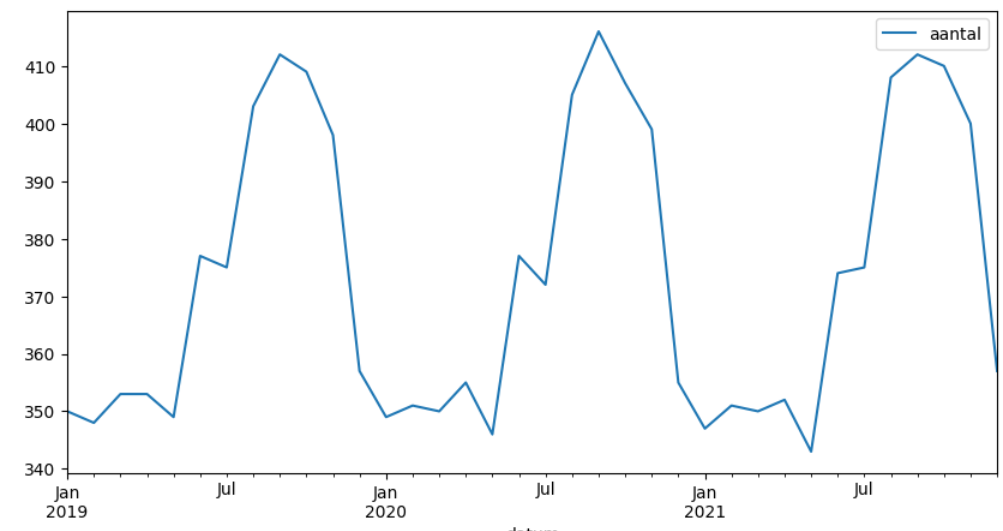

4. Make a forecast for the first four months of the next year using the most appropriate method. Explain why you chose this method.
5. Make a plot including the forecast.
6. Make the following calculations
- 6.1 Calculate the average number of employees in 2020
- 6.2 How many months did the company have more than 400 employees?




In [39]:
dfemployees = pd.DataFrame(data={
    'recording_date': ['2019/01/01', '2019/02/01', '2019/03/01', '2019/04/01', '2019/05/01', '2019/06/01', '2019/07/01', '2019/08/01', '2019/09/01', '2019/10/01', '2019/11/01', '2019/12/01', '2020/01/01', '2020/02/01', '2020/03/01', '2020/04/01', '2020/05/01', '2020/06/01', '2020/07/01', '2020/08/01', '2020/09/01', '2020/10/01', '2020/11/01', '2020/12/01', '2021/01/01', '2021/02/01', '2021/03/01', '2021/04/01', '2021/05/01', '2021/06/01', '2021/07/01', '2021/08/01', '2021/09/01', '2021/10/01', '2021/11/01', '2021/12/01'],
    'number': [350,348,353,353,349,377,375,403,412,409,398,357,349,351,350,355,346,377,372,405,416,407,399,355,347,351,350,352,343,374,375,408,412,410,400,357]
})

In [40]:
# 1. Give the data types of both columns
dfemployees.dtypes

,0
recording_date,object
number,int64


In [41]:
# 2. Convert the 'date' column to datetime type. Even if this fails you can continue working.
dfemployees['recording_date'] = pd.to_datetime(dfemployees['recording_date'])
dfemployees = dfemployees.set_index('recording_date')
dfemployees.head()

,number
recording_date,
2019-01-01,350
2019-02-01,348
2019-03-01,353
2019-04-01,353
2019-05-01,349


<Axes: xlabel='recording_date'>

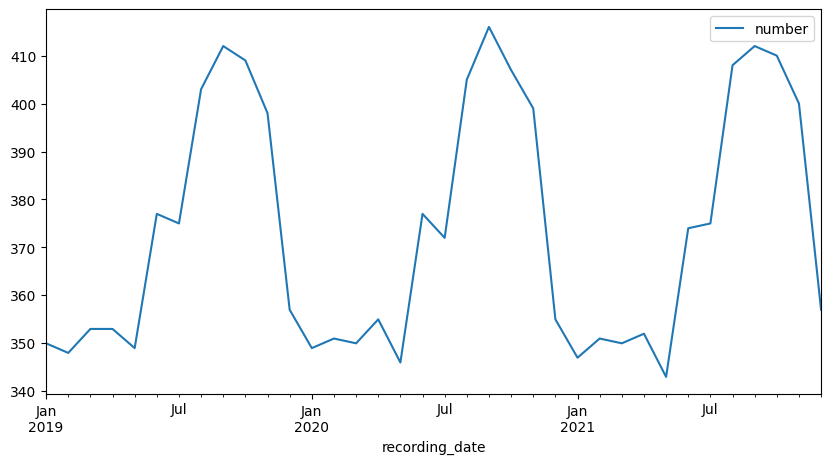

In [44]:
# 3. Create the plot. ( maar kan ook winters model -> bij seasonal maar zonder trend)
dfemployees.plot(y='number', figsize=[10,5])

In [47]:
# 4. Make a forecast for the first four months of the next year using the most appropriate method. Explain why you chose this method.
from statsmodels.tsa.holtwinters import ExponentialSmoothing

data_tes = ExponentialSmoothing(dfemployees, trend=None, seasonal='add', seasonal_periods=12, freq='MS').fit()

data_tes_fcast = data_tes.forecast(12)

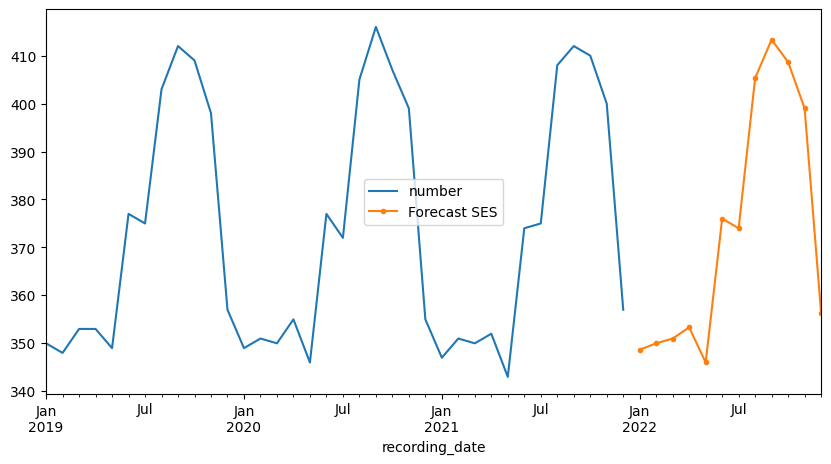

In [48]:
# 5. Make a plot including the forecast.
dfemployees.plot(y='number', figsize=[10, 5])
data_tes_fcast.plot(marker='.', legend=True, label='Forecast SES');

In [49]:
# 6. Make the following calculations
# - 6.1 Calculate the average number of employees in 2020
dfemployees['2020-01-01':'2020-12-01']['number'].mean()

np.float64(373.5)

In [ ]:
# - 6.2 How many months did the company have more than 400 employees?
dfemployees[dfemployees.number > 400]['number'].count()

## Question 3

In the Flanders Travel Behavior Survey (2021-2022) (Onderzoek Verplaatsingsgedrag Vlaanderen), we find the following figures related to the distribution of driver's license ownership by net income at the person level for persons aged 18 and over (excluding schoolchildren and students).  Is there a relationship between income and whether or not one has a driver's license?

1. What hypothesis test will you apply to answer this research question? Be as specific as possible!
2. Formulate the null hypothesis and the alternative hypothesis
3. Calculate the appropriate test statistic (test statistic) for this test. Provide the symbol and value
4. Calculate the p-value
5. Draw a conclusion based on the previous step and formulate an answer to the research question.
6. What percentage of those surveyed do not have a driver's license?

In [50]:
dfdriverlicense = pd.DataFrame(data={
    'income': ['0 - 1000 EUR', '1001 - 1500 EUR', '1501 - 2000 EUR', '2001 - 2500 EUR', '2501 - 3000 EUR', '>3000 EUR', 'does not want to answer this question'],
    'yes': [149, 469, 800, 653, 325, 270, 230],
    'no': [61, 157, 55, 20, 10, 4, 51]}).set_index('income')

In [ ]:
# 1. What hypothesis test will you apply to answer this research question? Be as specific as possible!
chi kwadraat test

In [ ]:
# 2. Formulate the null hypothesis and the alternative hypothesis
H0 = Er is geen verband tussen het hebben van een rijbewijs en het inkomen
H1 = Er is wel een verband tussen het hebben van een rijbewijs en het inkomen

In [55]:
# 3. Calculate the appropriate test statistic (test statistic) for this test. Provide the symbol and value
# 4. Calculate the p-value

#indien plot
#dfdriverlicense.plot(kind='barh')

chi2, p, df, expected = stats.chi2_contingency(dfdriverlicense)

print("Chi-squared        : %.4f" % chi2)
print("Degrees of freedom: %d" % df)
print("P-value            : %.11f" % p)

#of
print('----------------')

chi2, p, dof, expected = stats.chi2_contingency(dfdriverlicense)
g = stats.chi2.isf(alpha, df=dof)

print("Chi-squared        : %.4f" % chi2)
print("Degrees of freedom: %d" % dof)
print("P-value            : %.15f" % p)
print("criticical value   : %.4f" % g)#

Chi-squared        : 321.2331
Degrees of freedom: 6
P-value            : 0.00000000000
----------------
Chi-squared        : 321.2331
Degrees of freedom: 6
P-value            : 0.000000000000000
criticical value   : 12.5916


In [ ]:
# 5. Draw a conclusion based on the previous step and formulate an answer to the research question.
p ~ 0 => Er is voldoende reden om H0 te verwerpen. Er is voldoende reden om aan te nemen dat er een verband is tussen het inkomen en het hebben van een rijbewijs

In [56]:
# 6. What percentage of those surveyed do not have a driver's license?
geen_rijbewijs = dfdriverlicense['no'].sum()
wel_rijbewijs = dfdriverlicense['yes'].sum()

print(geen_rijbewijs, wel_rijbewijs)

358 2896


In [57]:
percentage = geen_rijbewijs * 1.0 / (geen_rijbewijs + wel_rijbewijs)
percentage

np.float64(0.11001843884449908)

## Question 4

Below are the restaurant scores for a number of New York City (NYC) and Long Island (LI) restaurants.

1. First, based on the scores for *eat*, *decor* and *service*, calculate the *total score*. **If you cannot calculate the total score, continue working with the score for food.**
2. Create the plot below.

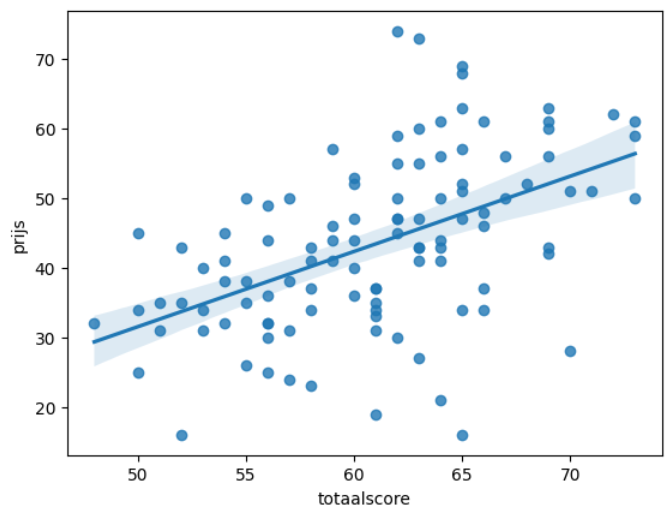

3. Use linear regression to try to predict the *price* based on the *total score*. Give the equation of the regression equation.
4. Give the estimated *price* for a *total score* = 70.
5. Calculate the correlation coefficient (symbol + value).
6. Give the interpretation for the value of the correlation coefficient.
7. List the number, minimum, maximum, mean, standard deviation, ... in the columns of quantitative variables.
8. The coefficient of variation is a dispersion measure that is independent of the unit in which data are expressed and is defined as the standard deviation divided by the mean. Calculate the coefficient of variation for *the score for eating*.
9. How many restaurants are there in New York City with a *price* higher than $65 (not including $65)?
10. Are *prices* in New York City significantly ($alpha = 0.05$) higher than in Long Island?

    - What statistical test will you use to determine this?
    - Formulate the null hypothesis and the alternative hypothesis
    - Calculate the excess probability $p$
    - Draw a conclusion based on this value and answer the research question.

In [58]:
dfrestaurants = pd.DataFrame(
    data={'restaurantname': ["101","12th St. Bar & Grill","202 Café","212","24 Prince","26 Seats","360","41 Greenwich Avenue","44","44 X Hell's Kitchen","5 Ninth","71 Irving Place","718","A.O.C.","A.O.C. Bedford","Abboccato","Abigael's","Above","Adrienne's Pizzabar","Aesop's Tables","Agata & Valentina Ristorante","Agave","Agnanti","Aix Brasserie","Aja","Aji Sushi","Areo","Bouley, Upstairs","Casa Mono","Cesca","Coals","Etats-Unis","Gari","Henry's End","ino","inoteca","Joya","Lupa","MarkJoseph Steakhouse","Noodle Pudding","Norma's","Osaka","Pearl Oyster Bar","Piccola Venezia","Po","Scalinatella","Sparks Steak House","Spigolo","Sushi Ann","Sushi Sen-nin","Tommaso","Wolfgang's Steakhouse","Yakitori Totto","105 Harbor","1770 House Restaurant & Inn","25 East American Bistro","56th Fighter Group","Abel Conklin's","Adirondack Grill","Akbar","Albert's Mandarin Gourmet","Allison's Ristorante","Almond","Amici","Aqua Blue Bar & Grill","Argyle Grill & Tavern","Ariana","Ayhan's Fish Kebab","Ayhan's Mediterranean Café","B. Smith's","Baang Café & Bar","Babylon Carriage House","Bamboo Restaurant & Sushi","Barney's","Barolo","Basil Leaf Café","Bay & Main","Bayou, The","Bayport House, The","Bayview Inn & Restaurant","Beacon","Bedlam Street Fish & Clam","Bella Vita City Grill","Bellport, The","Benihana","Benny's Ristorante","Maureen & Daughters Kitchen","Minami","Mirko's","Nisen","Palm","Plaza Café","Robert's","Rothmann's Steakhouse","Royal Tangra Masala","Sempre Vivolo","Soigne","Sole","Starr Boggs","Steve's Piccola Bussola","Stonewalls","Tellers American Chophouse","Trattoria Diane","Vine Street Café","Vintage Prime Steakhouse","Yuki's Palette"],
    'location': ["NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI"],
    'food': [20,21,21,17,18,23,23,18,20,21,20,19,22,19,23,23,20,18,24,22,18,19,24,21,20,21,25,25,25,23,25,25,26,25,24,23,25,25,25,25,25,25,26,25,25,25,25,25,25,25,25,25,25,20,24,16,14,22,16,19,23,19,21,22,18,21,20,20,18,16,22,21,20,26,24,18,19,22,21,24,20,22,21,24,17,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25],
    'decor': [18,19,17,17,17,16,15,18,22,18,22,17,19,16,21,20,16,19,17,18,16,19,15,21,23,14,20,16,18,21,17,16,17,14,14,18,19,18,17,18,20,17,14,17,16,17,19,16,17,15,18,20,19,22,25,20,21,17,21,17,18,19,15,18,17,21,17,17,15,23,23,24,18,23,20,17,15,16,21,21,19,19,17,19,17,18,19,21,21,20,18,21,21,22,14,22,24,15,24,15,21,26,21,15,21,15],
    'service': [17,20,18,16,15,19,19,19,18,19,17,16,19,16,21,21,18,18,17,20,14,18,19,20,20,20,21,18,20,21,19,23,19,24,18,20,20,21,23,22,21,20,19,23,21,21,21,21,21,20,22,20,20,20,23,17,16,21,16,18,22,21,18,21,17,19,20,19,17,17,19,18,18,24,22,19,18,18,20,24,18,21,20,21,19,24,21,24,23,21,23,24,21,22,18,24,24,21,20,21,23,22,22,23,23,21],
    'price': [38,36,32,45,34,37,38,35,52,43,57,16,40,35,51,61,45,50,23,44,32,36,34,59,43,26,48,46,47,57,19,56,74,43,25,37,21,50,63,34,37,30,41,52,47,73,68,55,60,53,47,69,44,50,62,40,31,47,31,32,27,44,41,33,43,35,31,30,25,49,43,41,44,59,46,38,35,32,47,42,50,45,41,41,34,50,16,28,63,34,61,51,56,60,24,51,50,34,56,37,43,61,52,55,61,31]})


In [64]:
# 1. First, based on the scores for *eat*, *decor* and *service*, calculate the *total score*. **If you cannot calculate the total score, continue working with the score for food.**
dfrestaurants['total'] = dfrestaurants['food'] + dfrestaurants['decor'] + dfrestaurants['service']
dfrestaurants.head()

#dfrestaurants['total'].sum()

np.int64(6465)

<Axes: xlabel='total', ylabel='price'>

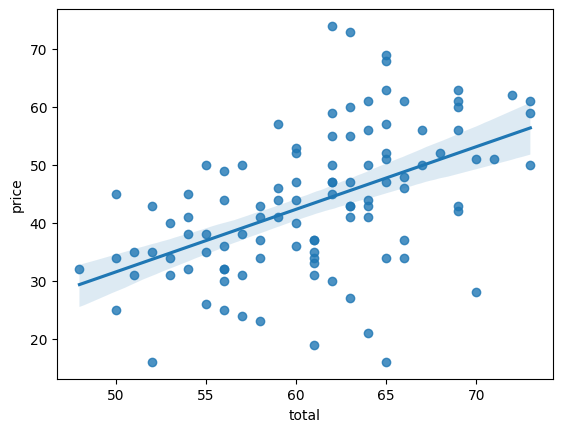

In [66]:
# 2. Create the plot below.
sns.regplot(data=dfrestaurants, x='total',y='price')

In [75]:
# 3. Use linear regression to try to predict the *price* based on the *total score*. Give the equation of the regression equation.
b1, b0 = np.polyfit(dfrestaurants.total, dfrestaurants.price, deg=1)
print(f'y = {b0} + {b1} * x')

y = -22.568833119352714 + 1.081716366690083 * x


In [74]:
# 4. Give the estimated *price* for a *total score* = 70.
price = b0 + (b1 * 70)
print(f'price = {price}')

price = 53.1513125489531


In [76]:
# 5. Calculate the correlation coefficient (symbol + value).
cor = np.corrcoef(
    dfrestaurants.total,
    dfrestaurants.price
)[0][1]

print(f"R ≈ {cor:.4f}")

R ≈ 0.5035


In [ ]:
# 6. Give the interpretation for the value of the correlation coefficient.
R > 0 => er is een stijgend verband
R ~ 0.5 => er is een middelmatig verband

In [77]:
# 7. List the number, minimum, maximum, mean, standard deviation, ... in the columns of quantitative variables.
dfrestaurants.describe()

,food,decor,service,price,total
count,106.000000,106.000000,106.000000,106.000000,106.000000
mean,22.471698,18.528302,19.990566,43.405660,60.990566
std,2.902241,2.712256,2.261459,12.411806,5.777617
min,14.000000,14.000000,14.000000,16.000000,48.000000
25%,20.000000,17.000000,18.000000,34.000000,56.250000
50%,23.500000,18.000000,20.000000,43.000000,61.500000
75%,25.000000,21.000000,21.000000,51.000000,65.000000
max,26.000000,26.000000,24.000000,74.000000,73.000000


In [78]:
# 8. The coefficient of variation is a dispersion measure that is independent of the unit in which data are expressed and is defined as the standard deviation divided by the mean. Calculate the coefficient of variation for *the score for eating*.
dfrestaurants['food'].std() / dfrestaurants['food'].mean()

np.float64(0.12915092815765816)

In [82]:
# 9. How many restaurants are there in New York City with a *price* higher than $65 (not including $65)?

#restos = (dfrestaurants['price'] > 65).sum()
#print(f"Number of restaurants with price > $65: {restos}")

dfrestaurants[(dfrestaurants.location == 'NYC') & (dfrestaurants.price > 65)]['location'].count()

Number of restaurants with price > $65: 4


np.int64(4)

In [86]:
#10. Are *prices* in New York City significantly ($alpha = 0.05$) higher than in Long Island?
prices_NY = dfrestaurants[dfrestaurants.location == 'NYC']['price'].values
prices_LI = dfrestaurants[dfrestaurants.location == 'LI']['price'].values

print(prices_NY)
print(prices_LI)

#two sample t-test (H5)
# greater / less - wij hebben greater want we verwachten de waarde groter te zijn in new york
stats.ttest_ind(alternative='greater', a=prices_NY, b=prices_LI)

#    - What statistical test will you use to determine this?
#    - Formulate the null hypothesis and the alternative hypothesis
#    - Calculate the excess probability $p$
#    - Draw a conclusion based on this value and answer the research question.

[38 36 32 45 34 37 38 35 52 43 57 16 40 35 51 61 45 50 23 44 32 36 34 59
 43 26 48 46 47 57 19 56 74 43 25 37 21 50 63 34 37 30 41 52 47 73 68 55
 60 53 47 69 44]
[50 62 40 31 47 31 32 27 44 41 33 43 35 31 30 25 49 43 41 44 59 46 38 35
 32 47 42 50 45 41 41 34 50 16 28 63 34 61 51 56 60 24 51 50 34 56 37 43
 61 52 55 61 31]


TtestResult(statistic=np.float64(0.585071488401949), pvalue=np.float64(0.2798834607871578), df=np.float64(104.0))

In [ ]:
# Stap 1
H0 = Er is geen verschil in prijzen tussen NY en LI
H1 = De prijzen in NY zijn significant hoger dan in LI

# Stap 2
alpha = 0.05

# Stap 3 (uit t-test result)
teststatistiek = 0.585

# Stap 4 (uit t-test result)
p = 0.2798

# Stap 4 Conclusie
p > 0.05, do not reject H0
Er is niet voldoende aanwijzing om H0 te verwerpen. De prijzen in NY zijn niet significant hoger dan in LI

<Axes: >

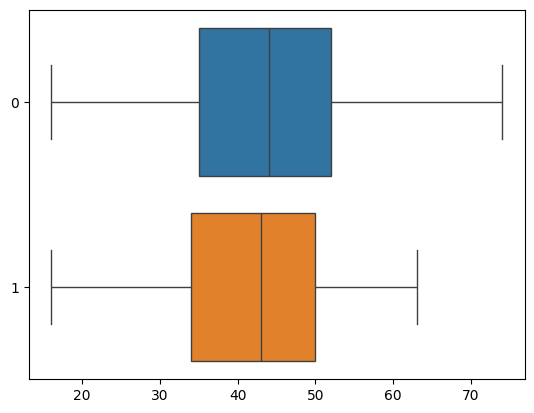

In [85]:
sns.boxplot([prices_NY, prices_LI], orient='h')